<a href="https://colab.research.google.com/github/avindumihisara0229-code/ErgoSense/blob/Tharusha/KKT_Deshapriya_DSGP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Feature extraction**

In [ ]:
!pip install librosa soundfile


In [ ]:
import os
import numpy as np
import pandas as pd
import librosa


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/archive/audio_speech_actors_01-24"


In [ ]:
def get_stress_label(filename):
    """
    Extract stress label from RAVDESS filename
    Stressed = Angry (05), Fearful (06)
    Not stressed = Neutral (01), Calm (02), Happy (03)
    """
    emotion_code = int(filename.split("-")[2])

    if emotion_code in [5, 6]:
        return 1  # Stressed
    elif emotion_code in [1, 2, 3]:
        return 0  # Not stressed
    else:
        return None  # Ignore other emotions


In [ ]:
def extract_features(file_path):
    # Load audio (use only first 3 seconds for consistency)
    y, sr = librosa.load(file_path, duration=3, offset=0.5)

    # MFCCs (13 coefficients)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfccs_mean = np.mean(mfccs, axis=1)

    # Pitch (fundamental frequency)
    pitches, _ = librosa.piptrack(y=y, sr=sr)
    pitch_mean = np.mean(pitches[pitches > 0]) if np.any(pitches > 0) else 0

    # Energy (RMS)
    energy = np.mean(librosa.feature.rms(y=y))

    # Tempo (speech rate)
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)

    # Combine all features into one vector
    return np.hstack([mfccs_mean, pitch_mean, energy, tempo])


In [ ]:
features = []
labels = []

for actor_folder in os.listdir(DATASET_PATH):
    actor_path = os.path.join(DATASET_PATH, actor_folder)

    if os.path.isdir(actor_path):
        for file in os.listdir(actor_path):
            if file.endswith(".wav"):
                label = get_stress_label(file)

                if label is not None:
                    file_path = os.path.join(actor_path, file)
                    feature_vector = extract_features(file_path)

                    features.append(feature_vector)
                    labels.append(label)


In [ ]:
feature_columns = [f"mfcc_{i}" for i in range(1, 14)]
feature_columns += ["pitch", "energy", "tempo"]

df = pd.DataFrame(features, columns=feature_columns)
df["stress"] = labels

df.head()


,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,pitch,energy,tempo,stress
0,-584.674011,63.550861,3.216504,12.510523,6.313325,0.937045,-17.175444,-8.413464,-6.622798,-10.023497,-1.402356,-3.117262,-5.184851,1548.881470,0.005284,67.999589,0
1,-531.203979,61.647114,-4.572315,2.740763,-2.088609,3.958043,-19.650618,-11.051280,-7.474490,-12.864723,2.031493,-10.209840,-4.990941,1490.485962,0.007827,184.570312,0
2,-515.324646,85.207718,-8.088744,9.528167,1.951334,-6.190319,-21.997009,-5.105417,-3.040505,-14.841343,12.985037,-9.392869,-5.627865,1536.403687,0.005880,89.102909,0
3,-592.081482,77.136101,4.449088,18.031532,10.912557,0.447543,-10.532049,-5.788989,-0.668430,-6.633837,-0.983075,-0.901634,-1.960368,1299.168213,0.004334,123.046875,0
4,-579.352417,77.645363,6.332064,13.562618,7.578548,-1.311473,-15.640059,-5.363317,-2.596069,-8.506312,4.690220,-6.763521,-3.690127,1483.194580,0.003516,112.347147,0


In [ ]:
df["stress"].value_counts()


,count
stress,
0,480
1,384


In [ ]:
df.to_csv("ravdess_stress_features.csv", index=False)
print("Feature extraction complete. CSV saved!")


Feature extraction complete. CSV saved!


In [ ]:
from google.colab import files
files.download("ravdess_stress_features.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Feature scaling + train/test split**


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [ ]:
X = df.drop("stress", axis=1)
y = df["stress"]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
print("Training data mean (approx 0):")
print(X_train_scaled.mean(axis=0)[:5])

print("\nTraining data std (approx 1):")
print(X_train_scaled.std(axis=0)[:5])


Training data mean (approx 0):
[-3.23908772e-16 -1.07969591e-16 -3.59898636e-17 -5.14140909e-17
 -1.02828182e-17]

Training data std (approx 1):
[1. 1. 1. 1. 1.]


**Handle class imbalance**

In [ ]:
print("Class distribution:")
print(y_train.value_counts())


Class distribution:
stress
0    384
1    307
Name: count, dtype: int64


In [ ]:
##Install imbalanced-learn
!pip install imbalanced-learn

In [ ]:
##Import SMOTE
from imblearn.over_sampling import SMOTE

In [ ]:
##Apply SMOTE (ONLY on training data)
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled, y_train
)


In [ ]:
##Verify balanced classes
print("After SMOTE:")
print(pd.Series(y_train_smote).value_counts())


After SMOTE:
stress
1    384
0    384
Name: count, dtype: int64


**Train ML models (SVM, Random Forest, Logistic Regression)**

In [ ]:
##Import ML models & metrics
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [ ]:
##Logistic Regression
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_smote, y_train_smote)


LogisticRegression(max_iter=1000)

In [ ]:
##Evaluate Logistic Regression

y_pred_lr = lr_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.7572254335260116

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.75      0.77        96
           1       0.71      0.77      0.74        77

    accuracy                           0.76       173
   macro avg       0.76      0.76      0.76       173
weighted avg       0.76      0.76      0.76       173


Confusion Matrix:
 [[72 24]
 [18 59]]


In [ ]:
##Support Vector Machine (SVM)
svm_model = SVC(kernel="rbf", C=1, gamma="scale")

svm_model.fit(X_train_smote, y_train_smote)


SVC(C=1)

In [ ]:
##Evaluate SVM
y_pred_svm = svm_model.predict(X_test_scaled)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))


SVM Accuracy: 0.8034682080924855

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.79      0.82        96
           1       0.76      0.82      0.79        77

    accuracy                           0.80       173
   macro avg       0.80      0.80      0.80       173
weighted avg       0.81      0.80      0.80       173


Confusion Matrix:
 [[76 20]
 [14 63]]


In [ ]:
##Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_smote, y_train_smote)


RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
##Evaluate Random Forest
y_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


Random Forest Accuracy: 0.8208092485549133

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.81      0.83        96
           1       0.78      0.83      0.81        77

    accuracy                           0.82       173
   macro avg       0.82      0.82      0.82       173
weighted avg       0.82      0.82      0.82       173


Confusion Matrix:
 [[78 18]
 [13 64]]


In [ ]:
##Compare all models (clean summary)
results = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_rf)
    ]
})

results


,Model,Accuracy
0,Logistic Regression,0.757225
1,SVM,0.803468
2,Random Forest,0.820809


In [ ]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    roc_auc_score,
    average_precision_score
)


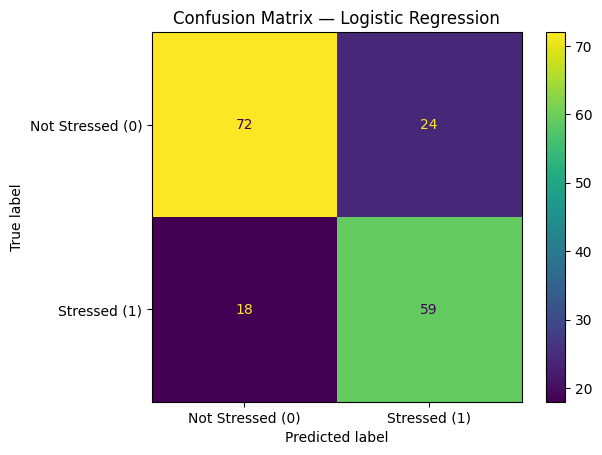

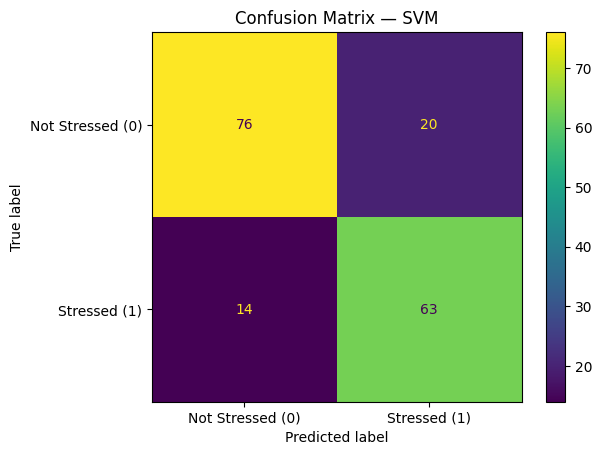

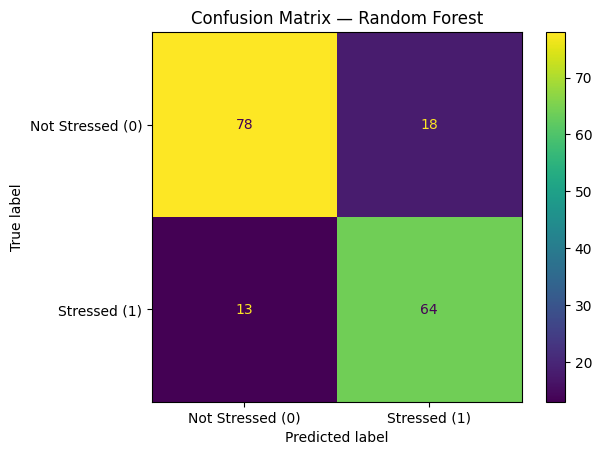

In [ ]:
models = {
    "Logistic Regression": lr_model,
    "SVM": svm_model,
    "Random Forest": rf_model
}

preds = {
    "Logistic Regression": y_pred_lr,
    "SVM": y_pred_svm,
    "Random Forest": y_pred_rf
}

for name in models:
    disp = ConfusionMatrixDisplay.from_predictions(
        y_test, preds[name],
        display_labels=["Not Stressed (0)", "Stressed (1)"],
        values_format="d"
    )
    plt.title(f"Confusion Matrix — {name}")
    plt.grid(False)
    plt.show()


In [ ]:
svm_model_prob = SVC(kernel="rbf", C=1, gamma="scale", probability=True, random_state=42)
svm_model_prob.fit(X_train_smote, y_train_smote)

# Probabilities for "stressed" class (class 1)
lr_scores = lr_model.predict_proba(X_test_scaled)[:, 1]
svm_scores = svm_model_prob.predict_proba(X_test_scaled)[:, 1]
rf_scores = rf_model.predict_proba(X_test_scaled)[:, 1]



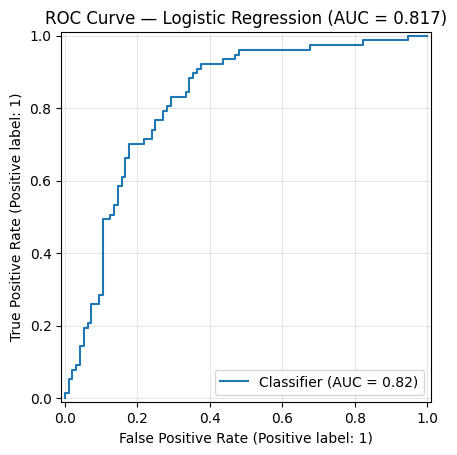

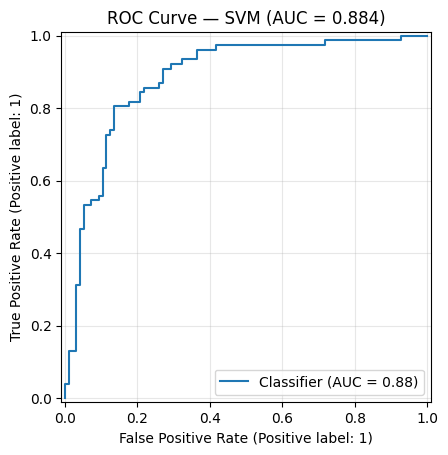

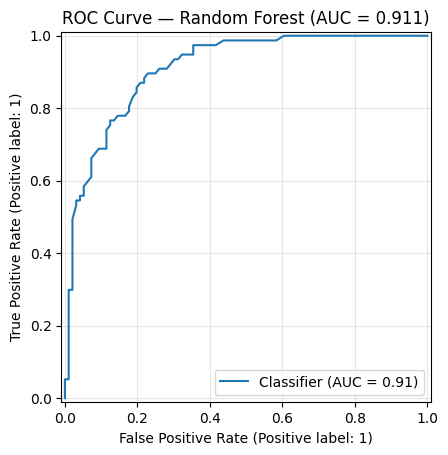

In [ ]:
score_dict = {
    "Logistic Regression": lr_scores,
    "SVM": svm_scores,
    "Random Forest": rf_scores
}

for name, scores in score_dict.items():
    RocCurveDisplay.from_predictions(y_test, scores)
    auc = roc_auc_score(y_test, scores)
    plt.title(f"ROC Curve — {name} (AUC = {auc:.3f})")
    plt.grid(True, alpha=0.3)
    plt.show()


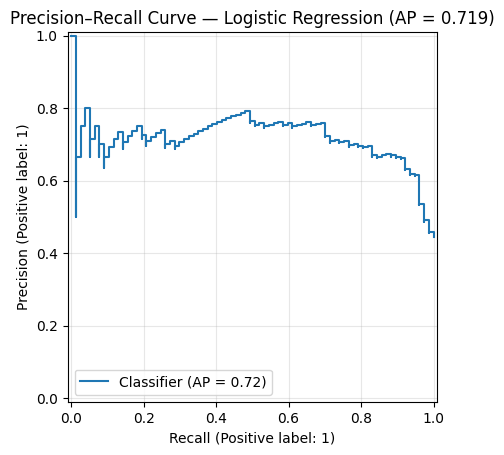

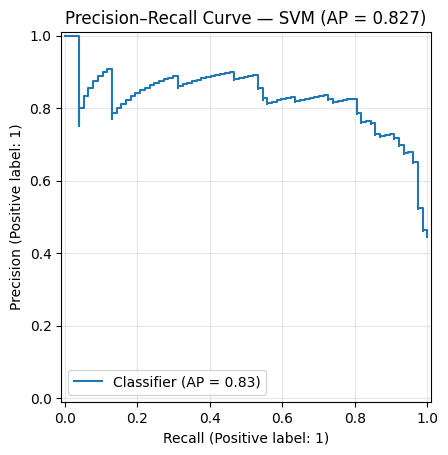

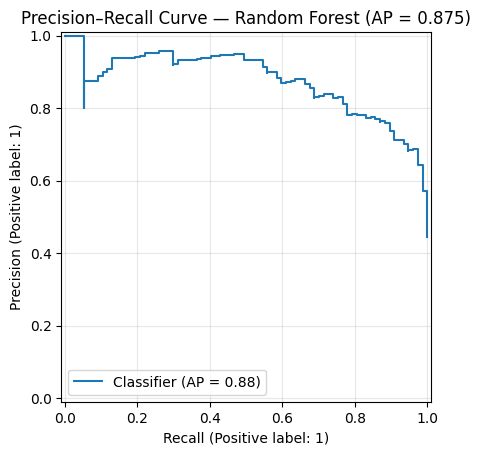

In [ ]:
for name, scores in score_dict.items():
    PrecisionRecallDisplay.from_predictions(y_test, scores)
    ap = average_precision_score(y_test, scores)
    plt.title(f"Precision–Recall Curve — {name} (AP = {ap:.3f})")
    plt.grid(True, alpha=0.3)
    plt.show()


<Figure size 800x600 with 0 Axes>

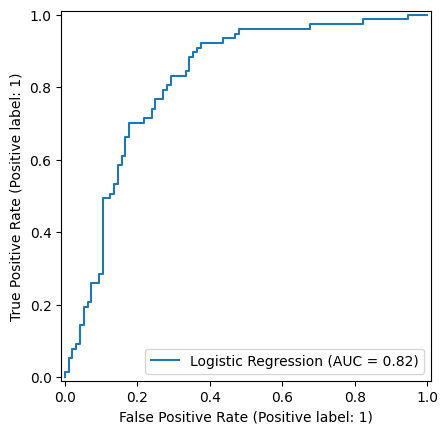

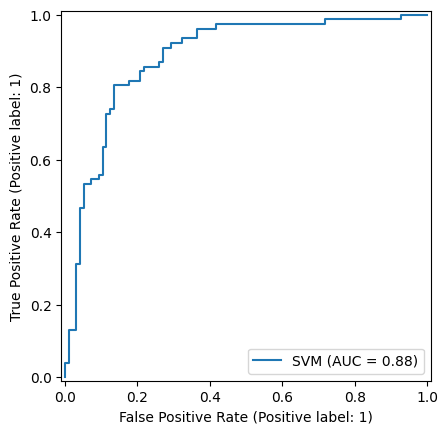

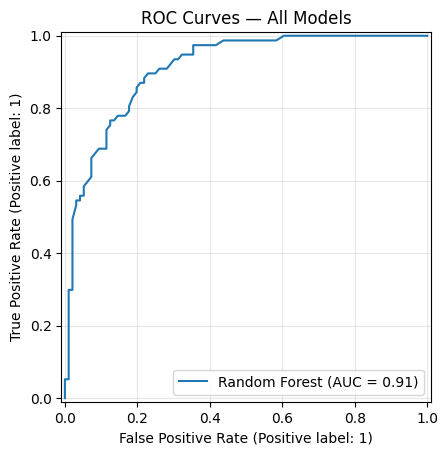

In [ ]:
plt.figure(figsize=(8, 6))

for name, scores in score_dict.items():
    RocCurveDisplay.from_predictions(y_test, scores, name=name)

plt.title("ROC Curves — All Models")
plt.grid(True, alpha=0.3)
plt.show()


<Figure size 800x600 with 0 Axes>

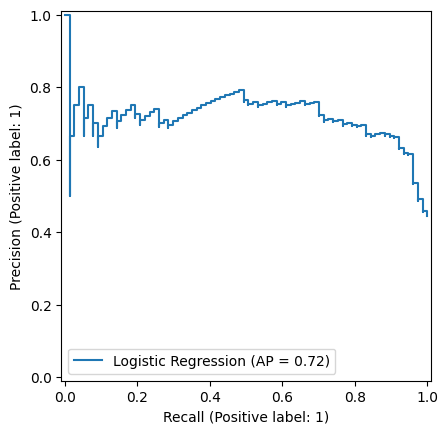

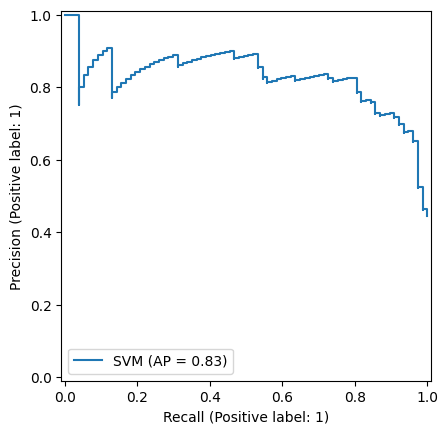

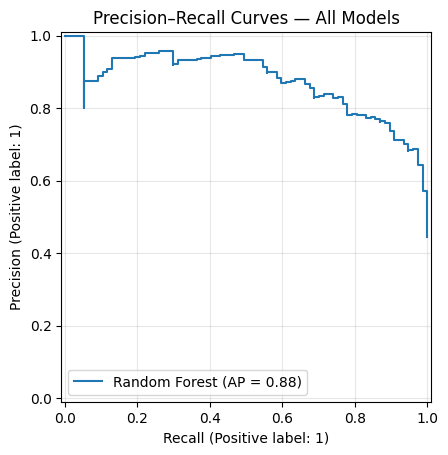

In [ ]:
plt.figure(figsize=(8, 6))

for name, scores in score_dict.items():
    PrecisionRecallDisplay.from_predictions(y_test, scores, name=name)

plt.title("Precision–Recall Curves — All Models")
plt.grid(True, alpha=0.3)
plt.show()
